# Análise Exploratória Inicial dos Microdados do ENEM 2023

**Projeto:** Análise de Dados Educacionais com Microdados do ENEM  
**Etapa:** Exploração inicial dos dados  
**Objetivo:** compreender a estrutura do conjunto de dados, identificar variáveis relevantes, avaliar valores ausentes e obter estatísticas descritivas iniciais.

---

## 1. Contextualização

Os microdados do ENEM disponibilizam informações sobre participantes, provas, notas, dados socioeconômicos e outras variáveis relevantes para análises educacionais.

Nesta primeira etapa, o foco será responder às seguintes perguntas iniciais:

1. Qual é a estrutura geral da base?
2. Quais colunas estão disponíveis?
3. Existem muitos valores ausentes?
4. Como se comportam as principais notas do ENEM?
5. Quais cuidados devem ser considerados antes da etapa de limpeza?

## 2. Preparação do Ambiente

Nesta seção são importadas as bibliotecas necessárias e definidos parâmetros de visualização para melhorar a leitura das tabelas no notebook.

In [62]:
# importações necessárias para a análise exploratória dos dados
import pandas as pd
from pathlib import Path 

# configurações de exibição do pandas para melhorar a visualização dos dados no notebook
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## 3. Carregamento dos Dados

A base utilizada corresponde aos **Microdados do ENEM 2023**.  
Para esta exploração inicial, será carregada uma amostra de `100.000` registros, o que permite uma análise mais leve e rápida durante o desenvolvimento.

In [63]:
# caminho para o arquivo CSV contendo os dados do ENEM 2023
DATA_PATH = Path("../data/raw/microdados_enem_2023/DADOS/MICRODADOS_ENEM_2023.csv")

NROWS = 100_000

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {DATA_PATH}\n"
        "Verifique se os microdados foram baixados e extraídos corretamente na pasta data/raw."
    )

# carregamento dos dados utilizando a biblioteca pandas
df = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="latin-1",
    nrows=NROWS
)

# exibição das primeiras linhas do DataFrame para verificar o carregamento dos dados
df.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,F,E,D,5,F,C,C,D,C,D,C,B,B,D,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,E,E,B,3,H,A,B,C,C,A,B,B,B,A,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4305108,Caxias do Sul,43,RS,1,1,1,1,"1,221.00","1,193.00","1,204.00","1,211.00",502.00,498.90,475.60,363.20,DBEBDCECCBCEBBBBDBABDDBBAABCBACDBACECCBAADEBB,ABDEADAADCDABDCADAEABCDDCBAADCCBEBCEBEBDBEAED,ACEBDCABAACAEBAECEBBBAAECBBDEADCAECCCEDDABEED,CEAEACCCDABCDAACEDDBAAEBABDDEEBDAECABDBCBCADE,1,DBEABDABDCACDBECDDDBCAAABBACCCADEBECCCEDAEEED,ACEEABAADCDAADEABCDABCDCABCBDADEBAECABADBCDAE,DBABBAEBAAAACDACDEDAACADBADBCCEACCCEAAECBBEBCA...,BCCDEEABCBEDCEABBEBDABDDADDADECAADDCCBEBEABCC,1.00,140.00,200.00,100.00,120.00,140.00,700.00,H,E,C,F,5,C,A,B,D,B,A,B,A,B,A,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,1.00,0,"2,304,400.00",Fortaleza,23.00,CE,2.00,1.00,1.00,2304400,Fortaleza,23,CE,1,1,1,1,"1,224.00","1,192.00","1,202.00","1,214.00",459.00,508.50,507.20,466.70,DEEBEACCCEBDDBDCCCAEEDCBAAADBCBEEEDCDAAECBEEC,DDAAEEBCCDEADBCDDCBAECABEBDEBDABECECEDCDDAEED,ADBDADAEEEACAABBACADCAEBBAAEBBCDEBBDDADDCADAA,EECBAEDEEDDDBBAADEECDBBBECEAACEAEECDBEDDBCDCB,0,CDDDABBABDBEABDECCEEEDCEDAEBABDCCAACCCADACDBE,DBAADEADCDCABABCDDEBAEABAECABAACECDAECBDAABCD,BBBDAABAEACCEEEDEACBCACAACAACAAAECBBEDBCCADBDE...,EBDADDAEBEACBEDCECCBEABCADEBCCBCCDEBDDAABBADD,1.00,140.00,200.00,160.00,180.00,200.00,880.00,D,D,B,B,5,C,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,1.00,0,"2,311,306.00",Quixadá,23.00,CE,2.00,1.00,1.00,2311306,Quixadá,23,CE,1,1,1,1,"1,222.00","1,191.00","1,201.00","1,212.00",402.50,379.20,446.90,338.30,AECCEAACDEABEEECDBAEEAAADDEABCBCEBACEEDCBEABD,CADEBCEDDEBCBAEBADDCECACADBDEBABDBDBEEDBBEADC,AABBACBCAEDABDADEDAACCAEEEECAACDCADBAEACDEAAE,CDBABEDCEEBBBDECDEBACCAABDEDCBECDECABBDBDEECC,0,CAAADCCCCDDDABDCACDBEEEDCEDAEECCDBEABDBABBAEB,CDAEECABAACEAADECBDAABCDCABADCDEABAABCDDEBADB,BBDABAAEBADACEEDCCDBADBDEDCCEBCACEACAACAACACBB...,DCECACCBDECBEEABEABDDAADDABBBCCBCCDDAEBDADEEB,1.00,120.00,120.00,120.00,120.00,80.00,560.00,B,B,A,A,4,B,A,B,A,A,A,B,A,A,A,A,A,A,B,A,A,B,A,A,A


## 4. Visão Geral da Base

A seguir, são avaliadas as dimensões do conjunto de dados e informações gerais sobre tipos de variáveis e preenchimento.

In [64]:
# dimensão da base carregada
linhas, colunas = df.shape

print(f"Quantidade de registros carregados: {linhas:,}")
print(f"Quantidade de colunas disponíveis: {colunas:,}")

Quantidade de registros carregados: 100,000
Quantidade de colunas disponíveis: 76


In [65]:
# exibição das informações gerais do DataFrame, como número de linhas, colunas e tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   NU_INSCRICAO            100000 non-null  int64  
 1   NU_ANO                  100000 non-null  int64  
 2   TP_FAIXA_ETARIA         100000 non-null  int64  
 3   TP_SEXO                 100000 non-null  str    
 4   TP_ESTADO_CIVIL         100000 non-null  int64  
 5   TP_COR_RACA             100000 non-null  int64  
 6   TP_NACIONALIDADE        100000 non-null  int64  
 7   TP_ST_CONCLUSAO         100000 non-null  int64  
 8   TP_ANO_CONCLUIU         100000 non-null  int64  
 9   TP_ESCOLA               100000 non-null  int64  
 10  TP_ENSINO               37113 non-null   float64
 11  IN_TREINEIRO            100000 non-null  int64  
 12  CO_MUNICIPIO_ESC        23030 non-null   float64
 13  NO_MUNICIPIO_ESC        23030 non-null   str    
 14  CO_UF_ESC               23030 no

## 5. Dicionário Inicial de Variáveis

A listagem abaixo permite visualizar todas as colunas disponíveis na amostra carregada.  
Essa etapa é importante para selecionar variáveis relevantes para as próximas análises.

In [66]:
# lista de colunas disponíveis no DataFrame
colunas_df = pd.DataFrame({
    "coluna": df.columns
})

colunas_df

,coluna
0,NU_INSCRICAO
1,NU_ANO
2,TP_FAIXA_ETARIA
3,TP_SEXO
4,TP_ESTADO_CIVIL
5,TP_COR_RACA
6,TP_NACIONALIDADE
7,TP_ST_CONCLUSAO
8,TP_ANO_CONCLUIU
9,TP_ESCOLA


## 6. Análise de Valores Ausentes

A identificação de valores nulos é uma etapa essencial da análise exploratória, pois orienta decisões futuras de tratamento, remoção ou imputação de dados.

In [67]:

# quantidade e percentual de valores ausentes por coluna
valores_ausentes = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("qtd_ausentes")
)

valores_ausentes["percentual_ausente"] = (
    valores_ausentes["qtd_ausentes"] / len(df) * 100
).round(2)

valores_ausentes.head(35)

,qtd_ausentes,percentual_ausente
SG_UF_ESC,76970,76.97
CO_UF_ESC,76970,76.97
NO_MUNICIPIO_ESC,76970,76.97
CO_MUNICIPIO_ESC,76970,76.97
TP_LOCALIZACAO_ESC,76970,76.97
TP_SIT_FUNC_ESC,76970,76.97
TP_DEPENDENCIA_ADM_ESC,76970,76.97
TP_ENSINO,62887,62.89
CO_PROVA_CN,24729,24.73
TX_GABARITO_MT,24729,24.73


## 7. Estatísticas Descritivas Gerais

Nesta etapa são calculadas medidas estatísticas das variáveis numéricas, como média, desvio padrão, valores mínimos, máximos e quartis.

In [68]:
# análise estatística descritiva das colunas numéricas do DataFrame
df.describe().T

,count,mean,std,min,25%,50%,75%,max
NU_INSCRICAO,"100,000.00","210,059,878,783.02","853,156.32","210,058,050,411.00","210,059,260,383.75","210,059,925,789.50","210,060,423,705.25","210,061,474,377.00"
NU_ANO,"100,000.00","2,023.00",0.00,"2,023.00","2,023.00","2,023.00","2,023.00","2,023.00"
TP_FAIXA_ETARIA,"100,000.00",5.09,3.54,1.00,3.00,4.00,6.25,20.00
TP_ESTADO_CIVIL,"100,000.00",1.03,0.38,0.00,1.00,1.00,1.00,4.00
TP_COR_RACA,"100,000.00",2.10,0.98,0.00,1.00,2.00,3.00,5.00
TP_NACIONALIDADE,"100,000.00",1.03,0.20,0.00,1.00,1.00,1.00,4.00
TP_ST_CONCLUSAO,"100,000.00",1.54,0.65,1.00,1.00,1.00,2.00,4.00
TP_ANO_CONCLUIU,"100,000.00",2.27,4.07,0.00,0.00,0.00,2.00,17.00
TP_ESCOLA,"100,000.00",1.42,0.56,1.00,1.00,1.00,2.00,3.00
TP_ENSINO,"37,113.00",1.01,0.08,1.00,1.00,1.00,1.00,2.00


## 8. Estatísticas das Notas do ENEM

Para uma análise inicial de desempenho, são selecionadas as principais colunas de notas:

- Ciências da Natureza
- Ciências Humanas
- Linguagens e Códigos
- Matemática
- Redação

In [69]:
# análise estatística descritiva das colunas de notas do ENEM
colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]

df[colunas_notas].describe().T

,count,mean,std,min,25%,50%,75%,max
NU_NOTA_CN,"75,271.00",493.62,85.63,0.00,438.90,488.90,546.20,868.40
NU_NOTA_CH,"78,202.00",527.48,85.74,0.00,473.50,532.80,586.50,823.00
NU_NOTA_LC,"78,202.00",520.49,73.34,0.00,474.80,523.90,570.40,758.60
NU_NOTA_MT,"75,271.00",527.21,128.08,0.00,427.65,512.90,618.20,958.60
NU_NOTA_REDACAO,"78,202.00",650.71,208.62,0.00,540.00,660.00,820.00,"1,000.00"


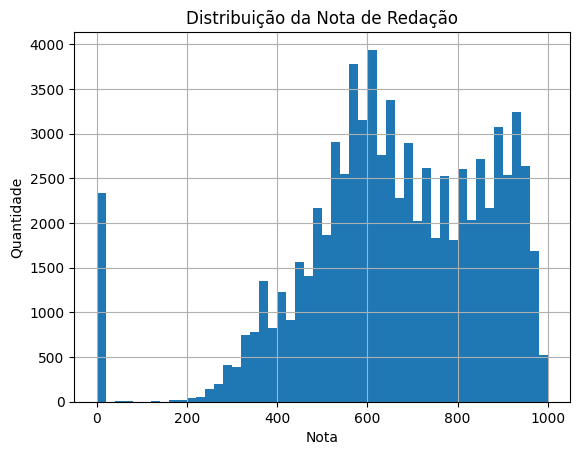

In [70]:
import matplotlib.pyplot as plt

# distribuição da nota de redação
df["NU_NOTA_REDACAO"].hist(bins=50)

plt.title("Distribuição da Nota de Redação")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

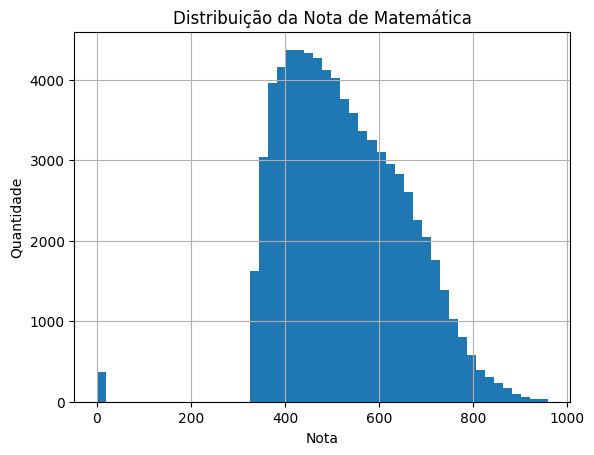

In [71]:
# distribuição da nota de matemática
df["NU_NOTA_MT"].hist(bins=50)

plt.title("Distribuição da Nota de Matemática")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

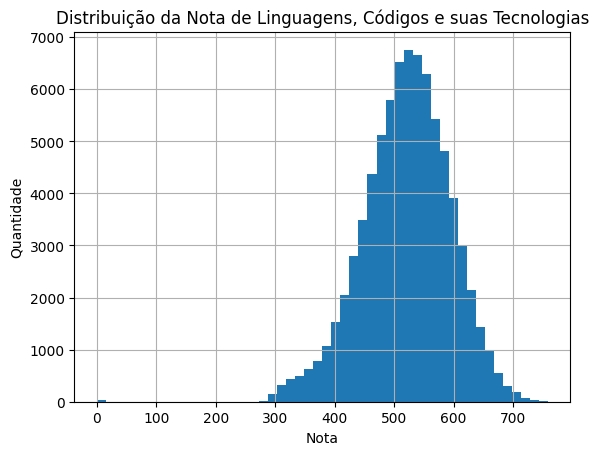

In [72]:
#distribuição da nota de linguagens, códigos e suas tecnologias
df["NU_NOTA_LC"].hist(bins=50)

plt.title("Distribuição da Nota de Linguagens, Códigos e suas Tecnologias")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

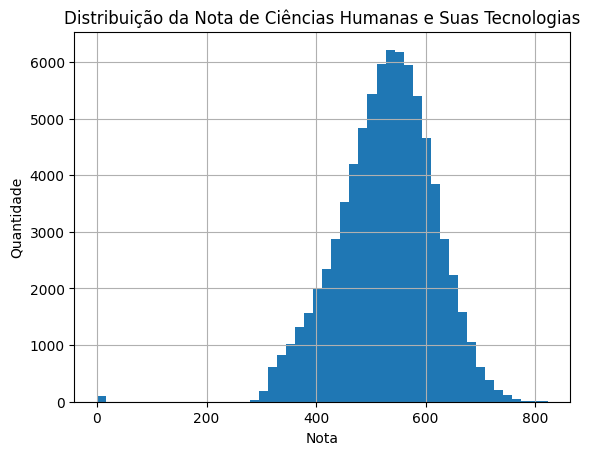

In [73]:
#distribuição da nota de ciências humanas e suas tecnologias
df["NU_NOTA_CH"].hist(bins=50)

plt.title("Distribuição da Nota de Ciências Humanas e Suas Tecnologias")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

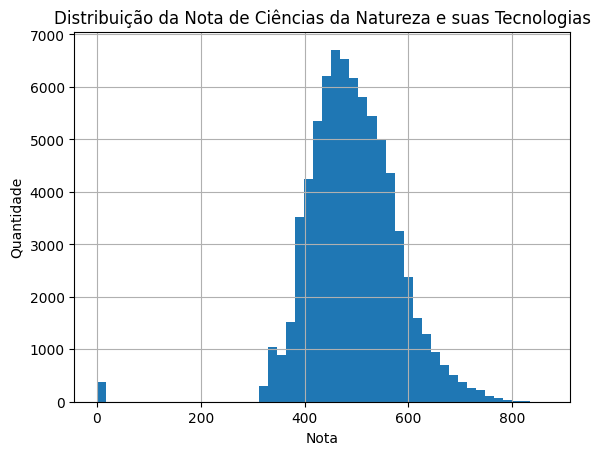

In [74]:
#distribuição da nota de ciências da natureza e suas tecnologias
df["NU_NOTA_CN"].hist(bins=50)

plt.title("Distribuição da Nota de Ciências da Natureza e suas Tecnologias")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()